# Issue 08 — Environmental Cost of Fast Trend Cycles

**Purpose:** Beat 4 ("who absorbs the cost")  
Three manually sourced, published figures tying the build-time/burn-time mechanism (from `08.1`) to its environmental cost. Unlike `08.1`/`08.2`, this isn't a live API/scrape pull, these are fixed published statistics from three separate reports, entered and cited manually.

**Sources (see `sources.md` for full citations):**
1. Nature Communications (peer-reviewed) — two SEPARATE figures from the same study, do not
   combine them as if one modifies the other:
   - The apparel industry leaked an estimated 8.3 million tons of plastic pollution into the
     environment in 2019 (14% of an estimated 60Mt global total, across all industries).
   - Synthetic apparel accounts for 89% of the industry's total plastic WASTE (18 of 21
     million tons), a related but different figure than the 8.3Mt leakage total.
2. Ellen MacArthur Foundation (2017, *A New Textiles Economy*, same report already cited for
   the "7–10 wears" figure in Issue #2). ~73% of discarded textiles end up in landfills or
   incinerators; less than 1% are recycled into new garments. Confirmed word-for-word
   against EMF's own site.
3. Cited in a 2024 U.S. GAO report, sourced from a separate federal study GAO reviewed (not
   GAO's own original finding). ~60% of textiles contain microplastics, which leach as
   they decompose in landfills.

**Note on the chart below:** these figures measure different things (a share of end-of-life
fate, a share of material composition, a share of a different total), not parts of one
whole. They're plotted as separate labeled bars rather than combined into a single stacked
total, combining them would imply a relationship the sources don't actually establish. The
8.3Mt leakage figure specifically is NOT one of the bars, it's a different unit (mass, not
%), tracked separately as a text callout for the slide instead.

## 1. Setup

In [11]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")

import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RAW_DIR = Path("../../../data/raw/cycle 2/issue-08")
PROCESSED_DIR = Path("../../../data/processed/cycle 2/issue-08")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load brand palette

In [12]:
# load brand palette
with open("../../../brand/palette.json") as f:
    palette_data = json.load(f)

palette = {c["name"]: c["hex"] for c in palette_data["palette"]}

COCOA = palette["Cocoa"]
DUSTY = palette["Dusty"]
PEACH = palette["Peach"]
CREAM = palette["Cream"]
SAGE  = palette["Sage"]

## 3. Extracting / analysing data

### 3.1 Manual inputs

Each figure is a fixed number from a single published report, not a pull from an API.
Double-check each value against `sources.md` before this goes anywhere near a slide.

In [13]:
stats = pd.DataFrame([
    {
        "metric": "Discarded textiles landfilled/incinerated",
        "value": 73,
        "unit": "%",
        "source": "Ellen MacArthur Foundation (2017, A New Textiles Economy)",
    },
    {
        "metric": "Discarded textiles recycled into new garments",
        "value": 1,  # EMF reports this as "<1%" — plotted at 1 as an upper bound, not exact
        "unit": "%",
        "source": "Ellen MacArthur Foundation (2017, A New Textiles Economy)",
    },
    {
        "metric": "Apparel industry's plastic waste that is synthetic",
        "value": 89,
        "unit": "%",
        "source": "Nature Communications (2024) — waste share, NOT the 8.3Mt leakage figure",
    },
    {
        "metric": "Textiles containing microplastics",
        "value": 60,
        "unit": "%",
        "source": "Cited in GAO (2024), sourced from a separate federal study",
    },
])
stats

,metric,value,unit,source
0,Discarded textiles landfilled/incinerated,73,%,"Ellen MacArthur Foundation (2017, A New Textil..."
1,Discarded textiles recycled into new garments,1,%,"Ellen MacArthur Foundation (2017, A New Textil..."
2,Apparel industry's plastic waste that is synth...,89,%,"Nature Communications (2024) — waste share, NO..."
3,Textiles containing microplastics,60,%,"Cited in GAO (2024), sourced from a separate f..."


### 3.2 Saving the raw inputs

In [14]:
raw_path = RAW_DIR / "environmental_stats.csv"
stats.to_csv(raw_path, index=False)
print(f"Saved to {raw_path}")

nature_comms_note = {
    "total_plastic_pollution_leaked_tons_2019": 8_300_000,
    "pct_of_global_cross_sector_total_60Mt": 14,
    "note": "This is the apparel industry's total leakage figure, separate from the 89% "
            "synthetic-waste-share figure in the main stats table — do not combine them.",
    "source": "Nature Communications (peer-reviewed), doi:10.1038/s41467-024-49441-4",
}
with open(RAW_DIR / "nature_comms_figure.json", "w") as f:
    json.dump(nature_comms_note, f, indent=2)

Saved to ..\..\..\data\raw\cycle 2\issue-08\environmental_stats.csv


## 4. Plot

### 4.1 Exploratory plot

The following is only for exploratory purposes. Three separately-sourced percentages, plotted as individual lebeled bars, not a stacked . combined total.

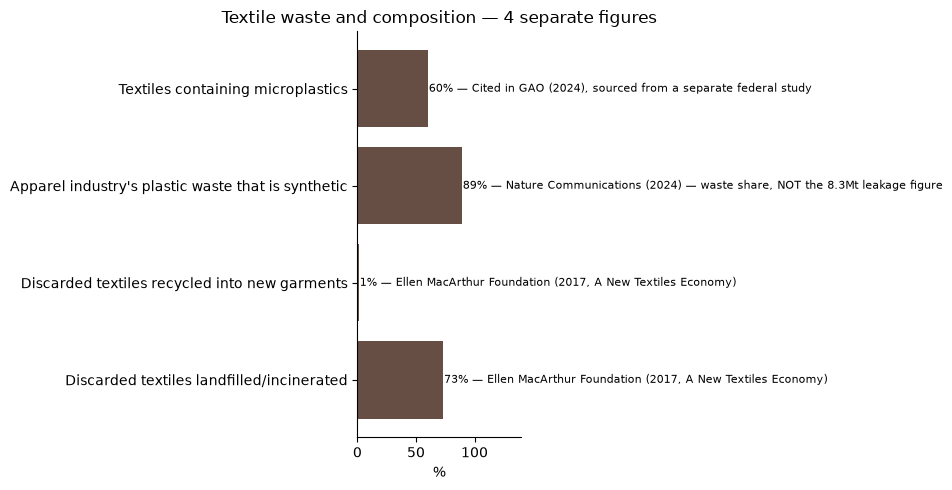

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(stats["metric"], stats["value"], color=COCOA)
ax.set_xlabel("%")
ax.set_title(f"Textile waste and composition — {len(stats)} separate figures")
ax.set_xlim(0, 140)  # was 0, 100 — the labels need space past each bar
for i, (val, src) in enumerate(zip(stats["value"], stats["source"])):
    ax.text(val + 1, i, f"{val}% — {src}", va="center", fontsize=8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.barh(stats["metric"], stats["value"], color=COCOA, height=0.5)

plt.tight_layout()
plt.savefig("../../../data/processed/cycle 2/issue-08/environmental_stats_chart.png",
            dpi=300, bbox_inches="tight")
plt.show()

### 4.2 Canva plot

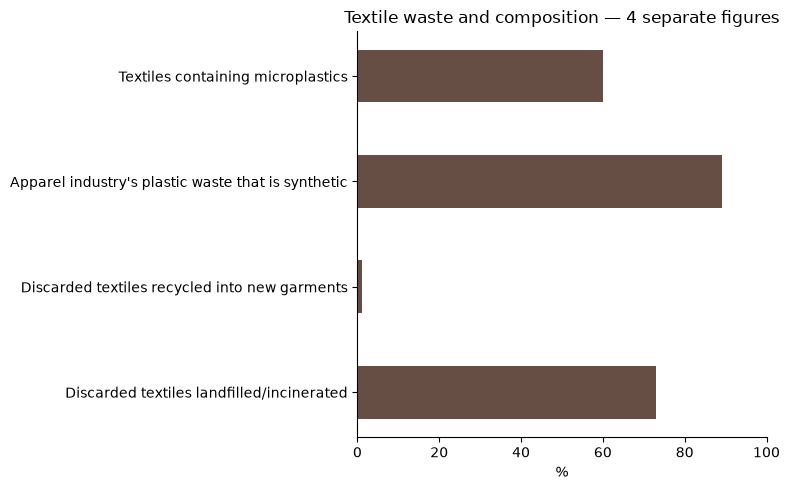

In [16]:
fig2, ax = plt.subplots(figsize=(8, 5))
ax.barh(stats["metric"], stats["value"], color=COCOA, height=0.5)
ax.set_xlabel("%")
ax.set_title(f"Textile waste and composition — {len(stats)} separate figures")
ax.set_xlim(0, 100)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../../../data/processed/cycle 2/issue-08/environmental_stats_chart_canva.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 5. Findings

- **Does the four-bar chart read clearly as four separate figures?** Yes. Each bar has its
  own label and source directly beside it, nothing visually implies the bars add up to a
  total. Title corrected to "4 separate figures" (was a stale "three," left over from before
  the Nature Comm 89% figure was added as its own bar).
- **Where does the 8.3Mt leakage callout land?** Not yet decided, still needs its own
  slide/callout treatment, separate from this chart (see intro cell note, it's a different
  unit and a different figure than the 89% bar shown here).
- **Design note for the final slide version:** the "<1% recycled" bar is so small it's
  nearly invisible at this scale, accurate, but risks reading as a rendering error rather
  than the point itself on a real slide. Consider a callout or annotation to make the
  near-zero value legible rather than relying on the bar alone.
- **Source accuracy re-check:** confirmed clean, EMF (2017), Nature Comm's 89% correctly
  isolated from the 8.3Mt figure, GAO correctly framed as relaying another federal source.